# 📊 Excel Sales Automation using Python

## Project Overview

This project demonstrates an end-to-end data analytics workflow using Python. The objective is to automate data cleaning, exploratory data analysis (EDA), data visualization, and Excel report generation using a retail sales dataset.

### Objectives

- Clean and validate sales data
- Explore sales performance
- Create meaningful visualizations
- Automate Excel reporting
- Generate business insights

### Tools

- Python
- Pandas
- Matplotlib
- OpenPyXL
- Google Colab

### Dataset

Sample Superstore Dataset

- Records : 9,994
- Variables : 13

# 📚 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font
from openpyxl.styles import PatternFill
from openpyxl.styles import Alignment
from openpyxl.chart import BarChart
from openpyxl.chart import Reference

# 📂 Load Dataset

In [20]:
df = pd.read_csv("SampleSuperstore.csv", sep=";")

In [21]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


# 🔍 Data Overview

In [22]:
df.head()

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Initial Observation

The dataset contains **9,994** transaction records with **13** variables representing customer, product, sales, and shipping information.

# ✅ Data Quality Check

In [23]:
df.isnull().sum()

duplicate_rows = df.duplicated().sum()

duplicate_rows

df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


### Findings

- Missing Values : 0
- Duplicate Records : 17
- Data types require adjustment for date columns.

# 🧹 Data Cleaning

### Split the combined column into separate columns

In [24]:
# Extract column names from the single column
combined_column_name = df_clean.columns[0]
column_names = combined_column_name.split(';')

# Split the single column into multiple columns
df_split = df_clean[combined_column_name].str.split(';', expand=True)
df_split.columns = column_names

# Concatenate with the original dataframe or replace the original column
df_clean = df_split.copy()

df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Ship Mode     9977 non-null   object
 1   Segment       9977 non-null   object
 2   Country       9977 non-null   object
 3   City          9977 non-null   object
 4   State         9977 non-null   object
 5   Postal Code   9977 non-null   object
 6   Region        9977 non-null   object
 7   Category      9977 non-null   object
 8   Sub-Category  9977 non-null   object
 9   Sales         9977 non-null   object
 10  Quantity      9977 non-null   object
 11  Discount      9977 non-null   object
 12  Profit        9977 non-null   object
dtypes: object(13)
memory usage: 1.1+ MB


In [25]:
df_clean = df.drop_duplicates()

In [26]:
df_clean.duplicated().sum()
df_clean.shape
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [27]:
df_clean["Profit"].sum()

np.float64(286241.4226)

### Cleaning Summary

✔ Removed duplicate records

✔ Converted Order Date into datetime format

✔ Converted Ship Date into datetime format

# 📈 Exploratory Data Analysis (EDA)

In [29]:
sales_region = (
    df_clean
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_region

,Sales
Region,
West,725255.6365
East,678435.1960
Central,500782.8528
South,391721.9050


In [30]:
profit_region = (
    df_clean
    .groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_region

,Profit
Region,
West,108329.8079
East,91506.3092
South,46749.4303
Central,39655.8752


In [31]:
sales_category = (
    df_clean
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_category

,Sales
Category,
Technology,836154.0330
Furniture,741306.3133
Office Supplies,718735.2440


In [32]:
profit_category = (
    df_clean
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122364.6608
Furniture,18421.8137


In [33]:
top_sub = (
    df_clean
    .groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sub

,Sales
Sub-Category,
Phones,330007.0540
Chairs,327777.7610
Storage,223843.6080
Tables,206965.5320
Binders,203409.1690
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


In [34]:
df_clean[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219662
Profit,-0.219662,1.000000


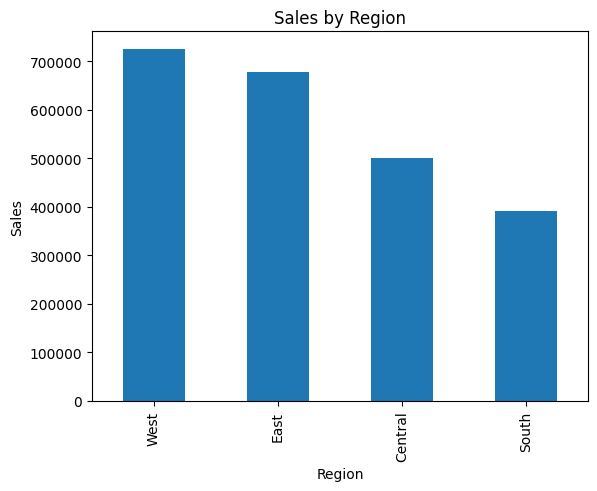

In [35]:
import matplotlib.pyplot as plt

sales_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

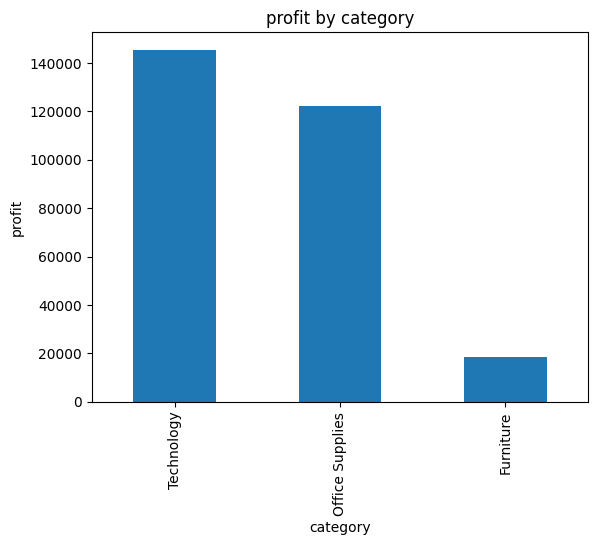

In [36]:
#Profit per Category
import matplotlib.pyplot as plt

profit_category.plot(kind="bar")

plt.title("profit by category")
plt.xlabel("category")
plt.ylabel("profit")

plt.show()

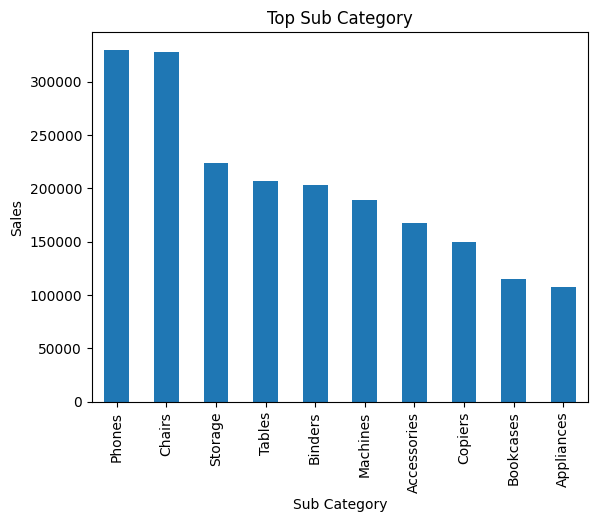

In [37]:
#Top Sub Category
import matplotlib.pyplot as plt

top_sub.plot(kind="bar")

plt.title("Top Sub Category")
plt.xlabel("Sub Category")
plt.ylabel("Sales")

plt.show()

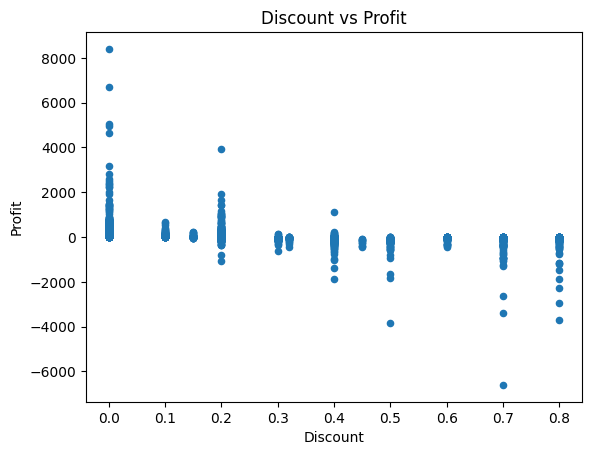

In [38]:
#Discount vs Profit
import matplotlib.pyplot as plt

df_clean.plot(kind="scatter", x="Discount", y="Profit")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

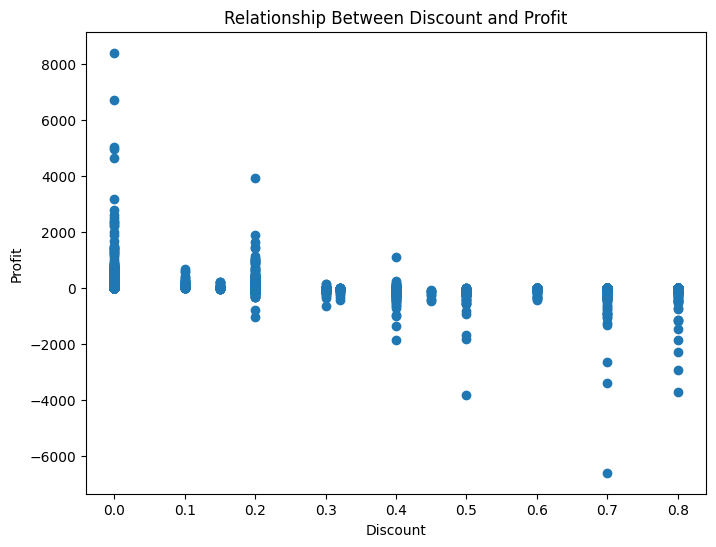

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df_clean["Discount"], df_clean["Profit"])

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Visualization Summary

The charts highlight regional sales performance and the relationship between discount and profitability.

In [40]:
summary = {
    "Total Sales": [df_clean["Sales"].sum()],
    "Total Profit": [df_clean["Profit"].sum()],
    "Average Sales": [df_clean["Sales"].mean()],
    "Average Profit": [df_clean["Profit"].mean()],
    "Duplicate Removed": [17]
}

summary_df = pd.DataFrame(summary)

summary_df

,Total Sales,Total Profit,Average Sales,Average Profit,Duplicate Removed
0,2.296196e+06,286241.4226,230.148902,28.69013,17


In [44]:
import os

output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

summary_df.to_excel(
    os.path.join(output_dir, "summary.xlsx"),
    index=False
)

In [45]:
summary_df.to_excel(
    "output/summary.xlsx",
    index=False
)

# ⚙ Excel Automation

In [46]:
!pip install openpyxl

In [47]:
from openpyxl import load_workbook
from openpyxl.styles import Font
from openpyxl.styles import PatternFill
from openpyxl.styles import Border
from openpyxl.styles import Side
from openpyxl.styles import Alignment

In [50]:
wb = load_workbook("output/Business_Report.xlsx")

In [51]:
ws = wb["Sales Region"]

In [53]:
header_fill = PatternFill(
    start_color="4F81BD",
    end_color="4F81BD",
    fill_type="solid"
)

In [54]:
header_font = Font(
    bold=True,
    color="FFFFFF"
)

In [55]:
for cell in ws[1]:
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal="center")

In [56]:
thin = Side(style="thin")

border = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

In [57]:
for row in ws.iter_rows():
    for cell in row:
        cell.border = border

In [58]:
for cell in ws["B"][1:]:
    cell.number_format = '#,##0.00'

In [59]:
wb.save("output/Business_Report_Final.xlsx")

In [60]:
from openpyxl.utils import get_column_letter

for column_cells in ws.columns:
    length = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
    ws.column_dimensions[get_column_letter(column_cells[0].column)].width = length + 2

In [61]:
wb.save("output/Business_Report_Final.xlsx")

In [62]:
summary_ws = wb.create_sheet("Executive Summary", 0)

In [63]:
summary_ws["A1"] = "BUSINESS REPORT"

summary_ws["A1"].font = Font(
    size=18,
    bold=True,
    color="FFFFFF"
)

summary_ws["A1"].fill = PatternFill(
    start_color="4F81BD",
    end_color="4F81BD",
    fill_type="solid"
)

summary_ws["A1"].alignment = Alignment(horizontal="center")

In [64]:
summary_ws.merge_cells("A1:D1")

In [65]:
summary_ws["A1"] = "BUSINESS REPORT"

summary_ws["A1"].font = Font(
    size=18,
    bold=True,
    color="FFFFFF"
)

summary_ws["A1"].fill = PatternFill(
    start_color="4F81BD",
    end_color="4F81BD",
    fill_type="solid"
)

summary_ws["A1"].alignment = Alignment(horizontal="center")

In [66]:
summary_ws.merge_cells("A1:D1")

In [67]:
summary_ws["A3"] = "Total Sales"
summary_ws["B3"] = df_clean["Sales"].sum()

summary_ws["A4"] = "Total Profit"
summary_ws["B4"] = df_clean["Profit"].sum()

summary_ws["A5"] = "Average Sales"
summary_ws["B5"] = df_clean["Sales"].mean()

summary_ws["A6"] = "Average Profit"
summary_ws["B6"] = df_clean["Profit"].mean()

summary_ws["A7"] = "Rows"
summary_ws["B7"] = df_clean.shape[0]

summary_ws["A8"] = "Columns"
summary_ws["B8"] = df_clean.shape[1]

In [68]:
for cell in ["B3","B4","B5","B6"]:
    summary_ws[cell].number_format = '#,##0.00'

In [69]:
for cell in ["A3","A4","A5","A6","A7","A8"]:
    summary_ws[cell].font = Font(bold=True)

In [70]:
wb.save("output/Business_Report_Final.xlsx")

In [71]:
from openpyxl.chart import BarChart, Reference

In [72]:
sales_ws = wb["Sales Region"]

In [73]:
chart = BarChart()
chart.title = "Sales by Region"

data = Reference(
    sales_ws,
    min_col=2,
    min_row=1,
    max_row=sales_ws.max_row
)

categories = Reference(
    sales_ws,
    min_col=1,
    min_row=2,
    max_row=sales_ws.max_row
)

chart.add_data(data, titles_from_data=True)
chart.set_categories(categories)

sales_ws.add_chart(chart, "D2")

In [74]:
wb.save("output/Business_Report_Final.xlsx")

# 💡 Business Insights

Sales by Region

West generated the highest total sales (725,255.64), while South recorded the lowest sales (391,721.91).

Discount vs Profit

Higher discounts generally resulted in lower profitability, with several high-discount transactions producing negative profit.

Recommendations

Maintain inventory in West.
Increase marketing in South.
Review discount strategy.

# 📌 Executive Summary

This project successfully demonstrates an end-to-end sales data analytics workflow using Python.

### Project Outcomes

✔ Processed 9,994 sales records

✔ Removed duplicate records

✔ Performed exploratory data analysis

✔ Built business visualizations

✔ Automated Excel report generation

✔ Produced actionable business insights